In [1]:
import kagglehub

path = kagglehub.dataset_download("datatattle/covid-19-nlp-text-classification")

print("Path to dataset files:", path)

c:\Users\nguye\miniconda3\envs\testenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\nguye\.cache\kagglehub\datasets\datatattle\covid-19-nlp-text-classification\versions\1


In [2]:
import os
import pandas as pd

print(os.listdir(path))

['Corona_NLP_test.csv', 'Corona_NLP_train.csv']


In [3]:
# Load CSV file

train_path = os.path.join(path, "Corona_NLP_train.csv")
test_path = os.path.join(path, "Corona_NLP_test.csv")

train_df = pd.read_csv(train_path, encoding="latin1")
test_df = pd.read_csv(test_path, encoding="latin1")

train_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [4]:
# Exploration

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [5]:
train_df["Sentiment"].value_counts()

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

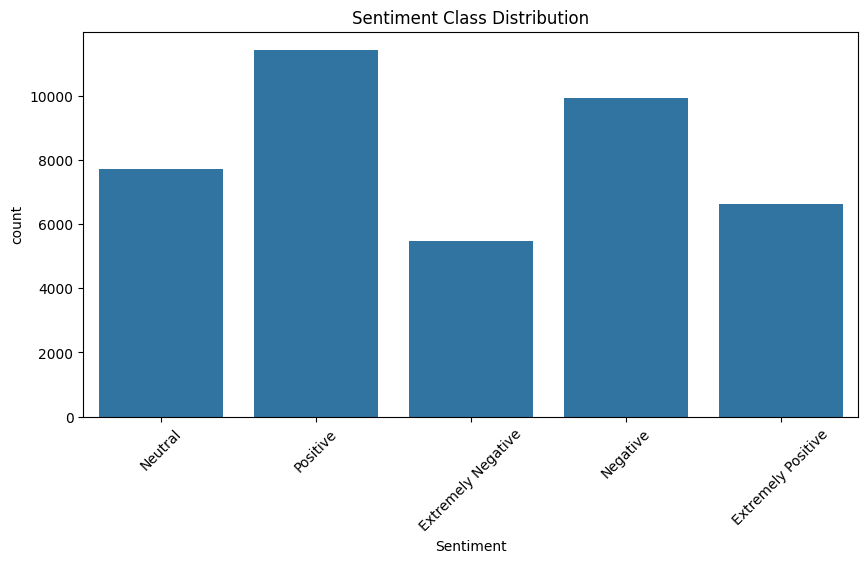

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x="Sentiment")
plt.xticks(rotation=45)
plt.title("Sentiment Class Distribution")
plt.show()

In [7]:
# only keep usefull columns

train_df = train_df[["OriginalTweet", "Sentiment"]]
test_df = test_df[["OriginalTweet", "Sentiment"]]

train_df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [8]:
import re

def clean_text(text):
    text = str(text).lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags symbol but keep the word
    text = re.sub(r"#", "", text)

    # remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
train_df["clean_text"] = train_df["OriginalTweet"].apply(clean_text)
test_df["clean_text"] = test_df["OriginalTweet"].apply(clean_text)

train_df.head()

,OriginalTweet,Sentiment,clean_text
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,and and
1,advice Talk to your neighbours family to excha...,Positive,advice talk to your neighbours family to excha...
2,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia woolworths to give elder...
3,My food stock is not the only one which is emp...,Positive,my food stock is not the only one which is emp...
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,me ready to go at supermarket during the covid...


In [10]:
def simplify_sentiment(sentiment):
    if sentiment in ["Extremely Negative", "Negative"]:
        return "Negative"
    elif sentiment == "Neutral":
        return "Neutral"
    else:
        return "Positive"

In [11]:
train_df["label"] = train_df["Sentiment"].apply(simplify_sentiment)
test_df["label"] = test_df["Sentiment"].apply(simplify_sentiment)

train_df["label"].value_counts()

label
Positive    18046
Negative    15398
Neutral      7713
Name: count, dtype: int64

In [12]:
# Encode target label

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])
y_test = label_encoder.transform(test_df["label"])

label_encoder.classes_

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [13]:
# TF-IDF vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

In [14]:
print(X_train.shape)
print(X_test.shape)

(41157, 10000)
(3798, 10000)


In [15]:
## Train logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter = 1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(
    y_test,
    y_pred_log,
    target_names=label_encoder.classes_
))

Accuracy: 0.7519747235387045
              precision    recall  f1-score   support

    Negative       0.80      0.74      0.77      1633
     Neutral       0.54      0.75      0.63       619
    Positive       0.83      0.76      0.79      1546

    accuracy                           0.75      3798
   macro avg       0.72      0.75      0.73      3798
weighted avg       0.77      0.75      0.76      3798



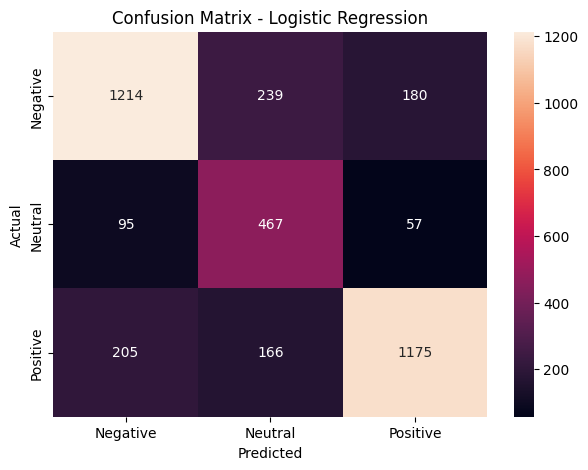

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()